In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import *
from ngsolve.webgui import Draw

from pathlib import Path
import os
import sys
sys.path.append(str(Path(os.getcwd()).parent / "src"))
from scipy.signal import find_peaks, peak_widths

In [3]:
from ngsolve.webgui import Draw
import utils
import myosin_actin_gel_fem
import importlib
import matplotlib.colors as mcolors

importlib.reload(myosin_actin_gel_fem)
importlib.reload(utils)

from myosin_actin_gel_fem import MyosinActinGel2D
from utils import plot_2d_frame, animate_2d, tanh_source

In [42]:
width = 0.05
center = 0.5
interfacial_width = 0.001
Lx = 1
Ly = 1

source = tanh_source(center=center, width=width, value=1, axis='x', interface_length=interfacial_width) * \
         tanh_source(center=center, width=Ly*0.9, value=1, axis='y', interface_length=0.1)

S = 0.8*source + 0.2
m0 = source

In [43]:
T   = 15
tau = 0.05
n_samples = 100

param_sets = [
    1.1, 1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55
]

conditions = [] 
for chi1 in [0.4*1, 0.4*0.8]: 
    sim_results = [] 
    for (i, Qsq) in enumerate(param_sets):
        print(f"Running simulation {i+1} with Qsq={Qsq}")
        sim = MyosinActinGel2D(
            width=1, height=1, maxh=0.03,
            
            # mechanics
            gamma = 1,
            eta_1 = 1,
            eta_2 = 0,
            chi0  = 0.08,
            chi1  = chi1,
            # nematic
            kappa = 1e-4,
            beta1 = 0.2,
            beta2 = 0.4,
            Qsq   = -1 + (Qsq**2+1)*source,
            # density / myosin
            S     = S,
            m0    = m0,
            k0    = 0.2,
            k1    = 0.8,
            k_m   = 0.5,
            n_hill = 4,
            m_ref  = 0.1,
            D_rho = 1e-4,
            D_m   = 1e-4,
            # base
            k     = 0.5,
            D     = 1e-3,
            rho0  = 1.0,
        )

        sim.simulate(
            tend=T,
            tau=tau,
            save_interval=int(1/tau)
        )
        data = sim.export(n_samples=n_samples)
        sim_results.append(data)
    conditions.append(sim_results)

Running simulation 1 with Qsq=1.1


  6%|▌         | 18/300 [00:00<00:03, 85.43it/s]

craete bilinearformapplication


100%|██████████| 300/300 [00:03<00:00, 90.41it/s]


Running simulation 2 with Qsq=1.0


...

100%|██████████| 300/300 [00:03<00:00, 98.89it/s] 


Running simulation 11 with Qsq=0.55


  7%|▋         | 21/300 [00:00<00:02, 101.51it/s]

craete bilinearformapplication


100%|██████████| 300/300 [00:03<00:00, 99.44it/s] 


In [56]:
n_mid = n_samples // 2
n_width = 4

def compute_depletion_widths(density, plot=False):
    threshold = np.max(density)*0.8
    selection = (density < threshold) 
    selection[n_mid-n_width:n_mid+n_width] = False  # Exclude the band region around the midline
    width = np.sum(selection)/2
    
    if plot: 
        plt.plot(density)
        threshold_line = np.full(len(density), threshold)
        threshold_masked = np.ma.masked_where(~selection, threshold_line)        
        plt.plot(threshold_masked, 'r--', linewidth=1)
        plt.axvline(x=n_mid-n_width, color='k', linestyle='--', linewidth=1)
        plt.axvline(x=n_mid-1+n_width, color='k', linestyle='--', linewidth=1)
        plt.axvspan(n_mid-n_width, n_mid-1+n_width, alpha=0.2, color='tab:orange')
        plt.show() 
    return width


collected_widths = []
collected_velocities = []
for i, condition in enumerate(conditions):
    sim_results = condition
    print(len(sim_results))
    densities = [sim_results[i]['rho'][-1, :, n_mid] for i in range(len(param_sets))]
    widths = np.array([compute_depletion_widths(density, plot=False) for density in densities])
    velocities = np.array([np.max((sim_results[i]['vx'][-1, n_mid:, n_mid])) for i in range(len(param_sets))])
    collected_widths.append(widths)
    collected_velocities.append(velocities)
collected_widths = np.array(collected_widths)
collected_velocities = np.array(collected_velocities)

11
11


In [57]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def two_color_colormap(color1, color2, name="custom_cmap"):
    """
    Create a linear colormap between two colors.

    Parameters:
        color1 (str or tuple): First color (e.g., "blue" or (0.1, 0.2, 0.5)).
        color2 (str or tuple): Second color (e.g., "red" or (0.8, 0.2, 0.3)).
        name (str): Name of the colormap.

    Returns:
        LinearSegmentedColormap: A matplotlib colormap object.
    """
    return LinearSegmentedColormap.from_list(name, [color1, color2])

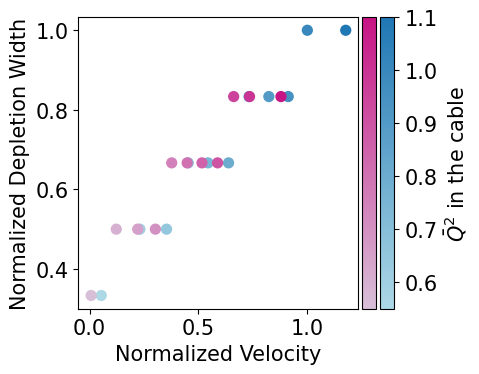

In [58]:
fig, ax1 = plt.subplots(figsize=(5, 4))

v0 = collected_velocities[0][1]
w0 = collected_widths[0][1]

cmaps = [
    two_color_colormap('lightblue', 'tab:blue'),
    two_color_colormap('thistle', 'mediumvioletred'),
]

for i, (cmap, w, v) in enumerate(zip(cmaps, collected_widths, collected_velocities)):
    sc = ax1.scatter(v/v0, w/w0, c=param_sets, cmap=cmap, s=50, vmin=min(param_sets), vmax=max(param_sets))
    if i == 0: 
        cb = plt.colorbar(sc, ax=ax1, label=r'$\bar{Q}^2$ in the cable', pad=-0.09)
    else: 
        cb = plt.colorbar(sc, ax=ax1, pad=0.01)
        cb.set_ticks([])

ax1.set_xlabel('Normalized Velocity')
ax1.set_ylabel('Normalized Depletion Width')

plt.tight_layout()
plt.savefig('../figures/velocity_depletion_width.svg')
plt.show()

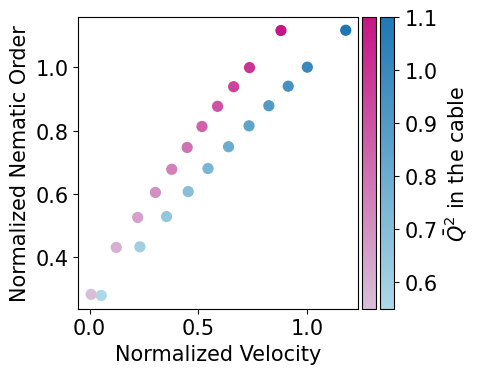

In [59]:
collected_nematics = np.array([
    np.array([np.max(np.abs(condition[i]['Q'][-1, n_mid, :])) for i in range(len(param_sets))])
    for condition in conditions
])

fig, ax1 = plt.subplots(figsize=(5, 4))

v0 = collected_velocities[0][1]
q0 = collected_nematics[0][1]

cmaps = [
    two_color_colormap('lightblue', 'tab:blue'),
    two_color_colormap('thistle', 'mediumvioletred'),
]

for i, (cmap, n, v) in enumerate(zip(cmaps, collected_nematics, collected_velocities)):
    sc = ax1.scatter(v/v0, n/q0, c=param_sets, cmap=cmap, s=50, vmin=min(param_sets), vmax=max(param_sets))
    if i == 0:
        cb = plt.colorbar(sc, ax=ax1, label=r'$\bar{Q}^2$ in the cable', pad=-0.09)
    else:
        cb = plt.colorbar(sc, ax=ax1, pad=0.01)
        cb.set_ticks([])

ax1.set_xlabel('Normalized Velocity')
ax1.set_ylabel('Normalized Nematic Order')

plt.tight_layout()
plt.savefig('../figures/velocity_nematic_order.svg')
plt.show()

In [61]:
np.savez('sim_data/caRhoA.npz', velocities=collected_velocities/v0, widths=collected_widths/w0, param_sets=np.array(param_sets), nematic=collected_nematics/q0)

In [39]:
T   = 15
tau = 0.05
n_samples = 100


sim = MyosinActinGel2D(
    width=1, height=1, maxh=0.03,
    
    # mechanics
    gamma = 1,
    eta_1 = 1,
    eta_2 = 0,
    chi0  = 0.08,
    chi1  = 0.4*0.8,
    # nematic
    kappa = 1e-4,
    beta1 = 0.2,
    beta2 = 0.4,
    Qsq   = -1 + (0.75**2+1)*source,
    # density / myosin
    S     = S,
    m0    = m0,
    k0    = 0.2,
    k1    = 0.8,
    k_m   = 0.5,
    n_hill = 4,
    m_ref  = 0.1,
    D_rho = 1e-4,
    D_m   = 1e-4,
    # base
    k     = 0.5,
    D     = 1e-3,
    rho0  = 1.0,
    )

sim.simulate(
    tend=T,
    tau=tau,
    save_interval=int(0.2/tau)
)
data = sim.export(n_samples=n_samples)

  7%|▋         | 22/300 [00:00<00:02, 105.53it/s]

craete bilinearformapplication


100%|██████████| 300/300 [00:03<00:00, 93.85it/s] 


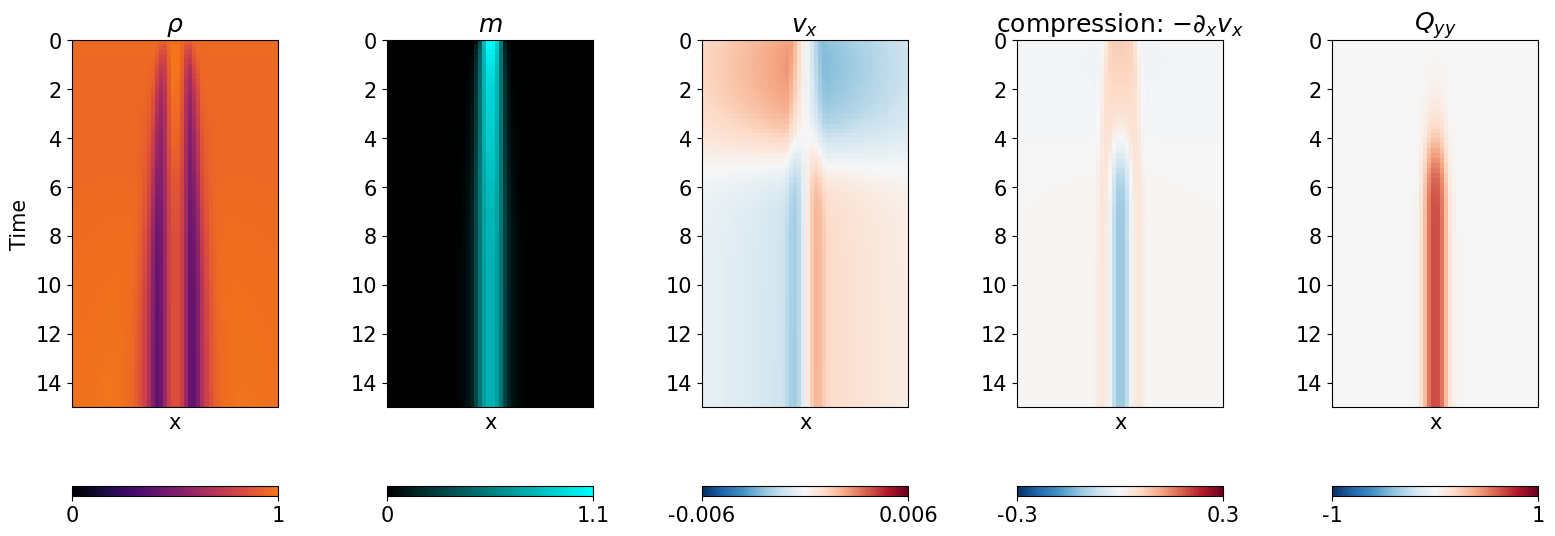

Maximum Q: 0.666122463679995


In [40]:
data2d = data

# Mid-line (y=0.5) profiles over time — same as 1D kymograph style
n = data2d['rho'].shape[2] // 2  # midline index
left = int((1- (100/135))*n_samples)
right = n_samples - left


compression = - np.gradient(data2d['vx'], axis=1)*n_samples 

import matplotlib.colors as mcolors
inferno_80 = mcolors.ListedColormap(plt.get_cmap('inferno')(np.linspace(0, 0.7, 256)))
black_cyan = mcolors.LinearSegmentedColormap.from_list("black_cyan", ["black", "cyan"])
    
plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(1, 5, figsize=(16, 6))

t_end = T 
fields = [
    (data2d['rho'][1:int(t_end/0.2), left:right, n], r'$\rho$',  inferno_80, dict(vmin=None, vmax=None)),
    (data2d['m'][1:int(t_end/0.2), left:right, n],   r'$m$',    black_cyan,  dict(vmin=None, vmax=None)),
    (data2d['vx'][1:int(t_end/0.2), left:right, n],  r'$v_x$',   'RdBu_r',   dict(vmin=-0.006, vmax=0.006)),
    (compression[1:int(t_end/0.2), left:right, n],   r'compression: $-\partial_x v_x$', 'RdBu_r', dict(vmin=-0.3, vmax=0.3)),
    (-data2d['Q'][1:int(t_end/0.2), left:right, n],   r'$Q_{yy}$','RdBu_r',  dict(vmin=-1, vmax=1)),
]

for ax, (field, title, cmap, kwargs) in zip(axes, fields):
    vmax = kwargs['vmax'] if kwargs['vmax'] is not None else np.max(np.abs(field))
    vmin = kwargs['vmin'] if kwargs['vmin'] is not None else (-vmax if cmap == 'RdBu_r' else 0)
    im = ax.imshow(field, aspect='auto', interpolation='none',
                   origin='upper', cmap=cmap, extent=(0, 1, T, 0),
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, location='bottom', pad=0.15,
                 ticks=[vmin, vmax], format='%.2g')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_xticks([]) 

axes[0].set_ylabel('Time')
plt.tight_layout()
plt.savefig('../figures/caRhoA_kymograph.svg', dpi=500, bbox_inches='tight')
plt.show()

print('Maximum Q:', np.max(-data2d['Q']))

dict_keys(['rho', 'm', 'vx', 'vy', 'comp', 'Q', 'q', 'x', 'y']) dict_keys(['rho', 'm', 'vx', 'vy', 'Q', 'q', 'x', 'y', 'comp'])


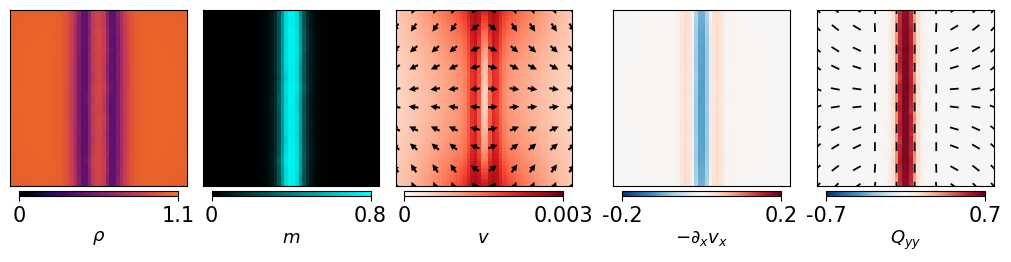

In [41]:
from utils import add_cbar, plot_2d_frame, animate_2d
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

fields = [
    ('rho',  r'$\rho$',                inferno_80),
    ('m',    r'$m$',                   black_cyan),
    ('v',    r'$v$',                   'Reds'),
    ('comp', r'$-\partial_x v_x$',     'RdBu_r'),
    ('Q',    r'$Q_{yy}$',             'RdBu_r'),
]


dx = data2d['x'][1] - data2d['x'][0]
data2d['comp'] = -np.gradient(data2d['vx'], dx, axis=1)
keys = ['rho', 'm', 'vx', 'vy', 'comp', 'Q', 'q']
cropped_data = {key: data2d[key][:, left:right, left:right] for key in keys}
cropped_data['x'] = data2d['x'][left:right]
cropped_data['y'] = data2d['y'][left:right]

print(cropped_data.keys(), data2d.keys())
plot_2d_frame(cropped_data, t=-1, fields=fields, title=f'', filename=f'../figures/caRhoA_2d.svg', n_arrows=10)